# 05 — Train OnsetsAndFrames (jongwook architecture)

This notebook trains the full OnsetsAndFrames model (jongwook variant with all
5 improvements over the 2018a paper).

**Training stages in this notebook:**

| Stage | `max_files` | Approx. data | Purpose |
|-------|-------------|--------------|----------|
| 0 — smoke | 5 | ~10 min | Verify training loop runs without errors |
| 1 — tiny | 30 | ~1 hr | Check model learns at all |
| 2 — small | 100 | ~4 hr | Tune hyperparameters |
| 3 — medium | 400 | ~20 hr | Compare O&F vs O&F-adv |
| 4 — full | None (all) | ~178 hr | Final results for dissertation |

Run stages 0→3 in order. Only run stage 4 after stage 3 confirms the model
scales correctly.

**All checkpoints are saved to Google Drive** so they survive Colab restarts.
Every run auto-creates a `runs/<run_name>/` directory with:
- `checkpoints/` — all saved `.pt` files + `best.pt`
- `plots/` — loss curve PNG after every epoch
- `metrics.json` — all epoch losses, updated live
- `config.json` — exact training config used

## Cell 1 — Environment setup

Run every session. Mounts Drive, installs packages, clones repo, sets paths.

In [1]:
# ── GPU check ─────────────────────────────────────────────────────────────
import torch
assert torch.cuda.is_available(), "No GPU! Change runtime to T4 GPU."
print(f"GPU : {torch.cuda.get_device_name(0)}")
print(f"CUDA: {torch.version.cuda}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU : Tesla T4
CUDA: 12.8
VRAM: 15.6 GB


In [2]:
# ── Mount Google Drive ─────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted ✓")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted ✓


In [3]:
# ── Clone / update repo ────────────────────────────────────────────────────
import os
from getpass import getpass

REPO_DIR = '/content/AMT_FYP'
TOKEN    = getpass('GitHub token: ')

if not os.path.exists(REPO_DIR):
    os.system(f"git clone https://{TOKEN}@github.com/Mobinmo83/AMT_FYP.git {REPO_DIR}")
    print(f"Cloned → {REPO_DIR}")
else:
    os.system(f"cd {REPO_DIR} && git pull")
    print(f"Pulled latest → {REPO_DIR}")

GitHub token: ··········
Pulled latest → /content/AMT_FYP


In [4]:
%cd /content/AMT_FYP/piano_amt
!pip install -q -r requirements.txt # torch torchaudio pretty_midi pandas tqdm matplotlib pyyaml mir_eval
print("Packages installed ✓")

/content/AMT_FYP/piano_amt
Packages installed ✓


In [5]:
# ── sys.path + project root ────────────────────────────────────────────────
import sys

PROJECT_ROOT = '/content/AMT_FYP/piano_amt'
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Quick sanity check
from src.constants import N_MELS, FRAMES_PER_SECOND, N_KEYS
assert N_MELS == 229 and abs(FRAMES_PER_SECOND - 31.25) < 1e-6 and N_KEYS == 88
print("Imports OK ✓")

Imports OK ✓


In [6]:
# ── Path constants  (edit ONLY these if your Drive layout differs) ──────────
DRIVE_ROOT   = '/content/drive/MyDrive/piano_amt'
MAESTRO_ROOT = f'{DRIVE_ROOT}/maestro-v3.0.0'
CACHE_DIR    = f'{DRIVE_ROOT}/cache'
RUNS_DIR     = f'{DRIVE_ROOT}/runs'

import os
os.makedirs(RUNS_DIR, exist_ok=True)

# Verify cache exists
import glob
npzs = glob.glob(f'{CACHE_DIR}/*.npz')
print(f"Cache files : {len(npzs)}")
assert len(npzs) > 0, "Run 02_build_cache.ipynb first!"
print(f"MAESTRO root: {MAESTRO_ROOT}")
print(f"Runs dir    : {RUNS_DIR}")

Cache files : 1276
MAESTRO root: /content/drive/MyDrive/piano_amt/maestro-v3.0.0
Runs dir    : /content/drive/MyDrive/piano_amt/runs


## Cell 2 — Training configuration

**Edit the `CONFIG` dict to choose your training stage.**

Key parameters:
- `run_name`: unique name saved to Drive — use descriptive names like `of_baseline_stage1`
- `max_files`: controls dataset size (None = full 962 training files)
- `model_complexity`: 48 = full jongwook model (~26M params); 16 = small debug model (~1M params)
- `epochs`: use fewer epochs for smoke/tiny tests; 30+ for real training
- `resume`: path to a `.pt` checkpoint to resume from; None to start fresh

In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# TRAINING CONFIGURATION — edit this cell
# ═══════════════════════════════════════════════════════════════════════════

CONFIG = {
    # ── Identity ───────────────────────────────────────────────────────────
    # Choose a descriptive name; results saved to RUNS_DIR/<run_name>/
    'run_name':   'of_baseline_smoke',   # <-- CHANGE THIS each run

    # ── Dataset size ──────────────────────────────────────────────────────
    # Stage 0 (smoke): max_files=5     (~10 min audio, 2 epochs, verify loop)
    # Stage 1 (tiny):  max_files=30    (~1 hr audio, 5 epochs)
    # Stage 2 (small): max_files=100   (~4 hr audio, 15 epochs)
    # Stage 3 (medium):max_files=400   (~20 hr audio, 30 epochs)
    # Stage 4 (full):  max_files=None  (~178 hr audio, 30+ epochs)
    'max_files':  5,

    # ── Model ─────────────────────────────────────────────────────────────
    # 48 = full jongwook (~26M params) — use for stage 2+
    # 16 = small debug (~1M params) — use for stage 0+1 to move faster
    'model_complexity': 16,

    # ── Training ─────────────────────────────────────────────────────────
    'epochs':        2,      # smoke=2, tiny=5, small=15, medium=30, full=30+
    'batch_size_train': 4,   # for training (can be 8 on better GPUs)
    'batch_size_val':   1,   # for validation (MUST be 1)
    'lr':            6e-4,   # Hawthorne 2018a §3.2
    'pos_weight':    5.0,
    'max_grad_norm': 3.0,
    'num_workers':   2,
    'log_every':     10,     # print loss every N steps

    # ── Resume from checkpoint (set to None to start fresh) ───────────────
    # Example: f'{RUNS_DIR}/of_baseline_stage1/checkpoints/best.pt'
    'resume': None,
}

# ─── Print config summary ─────────────────────────────────────────────────
print("Training configuration:")
for k, v in CONFIG.items():
    print(f"  {k:20s}: {v}")

Training configuration:
  run_name            : of_baseline_smoke
  max_files           : 5
  model_complexity    : 16
  epochs              : 2
  batch_size_train    : 4
  batch_size_val      : 1
  lr                  : 0.0006
  pos_weight          : 5.0
  max_grad_norm       : 3.0
  num_workers         : 2
  log_every           : 10
  resume              : None


## Cell 3 — Build model and inspect

In [8]:
import torch
from models.onsets_frames.model import OnsetsAndFrames

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = OnsetsAndFrames(model_complexity=CONFIG['model_complexity'])

n_params = model.count_parameters()
print(f"Model          : OnsetsAndFrames")
print(f"model_complexity: {CONFIG['model_complexity']}")
print(f"Parameters     : {n_params:,}")
print(f"Device         : {device}")

# Quick forward pass to check shapes
model = model.to(device)
dummy = torch.zeros(2, 229, 640).to(device)
with torch.no_grad():
    out = model(dummy)
for k, v in out.items():
    print(f"  {k:10s}: {tuple(v.shape)}  min={v.min():.3f} max={v.max():.3f}")

assert out['onset'].shape  == (2, 640, 88), "Onset shape wrong"
assert out['frame'].shape  == (2, 640, 88), "Frame shape wrong"
assert out['offset'].shape == (2, 640, 88), "Offset shape wrong"
print("\nModel shapes OK ✓")

Model          : OnsetsAndFrames
model_complexity: 16
Parameters     : 3,204,856
Device         : cuda
  onset     : (2, 640, 88)  min=0.474 max=0.521
  frame     : (2, 640, 88)  min=0.438 max=0.557
  offset    : (2, 640, 88)  min=0.480 max=0.524
  velocity  : (2, 640, 88)  min=-0.109 max=0.097

Model shapes OK ✓


## Cell 4 — Build DataLoaders

In [9]:
from src.dataloader import get_dataloader

train_loader = get_dataloader(
    maestro_root   = MAESTRO_ROOT,
    split          = 'train',
    batch_size     = CONFIG['batch_size_train'],
    num_workers    = CONFIG['num_workers'],
    cache_dir      = CACHE_DIR,
    max_files      = CONFIG['max_files'],
    use_augmentation = True,
    pin_memory     = True,
)
val_loader = get_dataloader(
    maestro_root   = MAESTRO_ROOT,
    split          = 'validation',
    batch_size     = CONFIG['batch_size_val'],
    num_workers    = CONFIG['num_workers'],
    cache_dir      = CACHE_DIR,
    max_files      = CONFIG['max_files'],
    use_augmentation = False,
    pin_memory     = True,
)
print(f"Train batches : {len(train_loader)}  (batch_size={CONFIG['batch_size_train']})")
print(f"Val batches   : {len(val_loader)}")

# Peek at one batch
batch = next(iter(train_loader))
print(f"\nSample batch:")
for k, v in batch.items():
    if hasattr(v, 'shape'):
        print(f"  {k:12s}: {tuple(v.shape)}")
print("DataLoaders OK ✓")

Train batches : 1  (batch_size=4)
Val batches   : 5

Sample batch:
  mel         : (4, 229, 640)
  onset       : (4, 640, 88)
  frame       : (4, 640, 88)
  offset      : (4, 640, 88)
  velocity    : (4, 640, 88)
DataLoaders OK ✓


## Cell 5 — Train

This cell runs the full training loop.  
Loss curves are saved to Drive after every epoch — if Colab disconnects,
you can resume from `best.pt` by setting `CONFIG['resume']` above.

**Watch:** the `[ep NNN step NNN]` lines show per-batch loss in real time.

In [10]:
from models.onsets_frames.train import OnsetsFramesLoss, Trainer, RunDirectory

# Create run directory
run_dir = RunDirectory(RUNS_DIR, CONFIG['run_name'])

# Save config
import json
cfg_to_save = dict(CONFIG)
cfg_to_save.update({'maestro_root': MAESTRO_ROOT, 'cache_dir': CACHE_DIR,
                    'device': str(device)})
run_dir.save_config(cfg_to_save)

# Fresh model
model = OnsetsAndFrames(model_complexity=CONFIG['model_complexity'])

# Trainer with GPU optimizations
trainer = Trainer(
    model          = model,
    train_loader   = train_loader,
    val_loader     = val_loader,
    device         = device,
    run_dir        = run_dir,
    lr             = CONFIG['lr'],
    pos_weight     = CONFIG['pos_weight'],
    max_grad_norm  = CONFIG['max_grad_norm'],
    log_every      = CONFIG['log_every'],
    use_amp        = True,
    use_compile    = True,
)

# Resume from checkpoint if specified
start_epoch = 1
if CONFIG['resume']:
    ckpt_path = CONFIG['resume']
    print(f"Resuming from: {ckpt_path}")
    ckpt = torch.load(ckpt_path, map_location=device)

    # Handle torch.compile wrapper
    model_to_load = trainer.model
    if hasattr(trainer.model, '_orig_mod'):
        model_to_load = trainer.model._orig_mod
    model_to_load.load_state_dict(ckpt['model_state'])

    if 'optimizer_state' in ckpt:
        trainer.optimizer.load_state_dict(ckpt['optimizer_state'])
    if 'scheduler_state' in ckpt:
        trainer.scheduler.load_state_dict(ckpt['scheduler_state'])
    if 'scaler_state' in ckpt and trainer.scaler is not None:
        trainer.scaler.load_state_dict(ckpt['scaler_state'])

    start_epoch = ckpt['epoch'] + 1
    trainer.global_step = ckpt.get('global_step', 0)
    trainer.best_val_loss = ckpt.get('best_val_loss', ckpt.get('val_loss', float('inf')))
    print(f"  Resumed at epoch {start_epoch}, best_val_loss={trainer.best_val_loss:.4f}")

trainer.fit(epochs=CONFIG['epochs'], start_epoch=start_epoch)

print(f"\n\u2713 Training complete. Run directory: {run_dir.root}")
print(f"  Best val loss : {trainer.best_val_loss:.4f}")
print(f"  Best checkpoint: {run_dir.best_checkpoint_path()}")


Starting training: epochs 1→2
Run directory: /content/drive/MyDrive/piano_amt/runs/of_baseline_smoke
Best val loss so far: inf
Cumulative training time: 0.0s

--- Epoch 1/2 ---
  train=2.6837  val=2.2604  lr=6.00e-04  time=24s  ETA: ~0min ★ NEW BEST

--- Epoch 2/2 ---
  train=2.4069  val=2.1509  lr=6.00e-04  time=3s ★ NEW BEST


  TRAINING COMPLETE
  Run directory     : /content/drive/MyDrive/piano_amt/runs/of_baseline_smoke
  Epochs trained    : 1→2 (2 epochs)
  Best val loss     : 2.1509 (epoch 2)
  Session time      : 0.5 min
  Total train time  : 0.01 hours

  Saved files:
    ✓ Config: /content/drive/MyDrive/piano_amt/runs/of_baseline_smoke/config.json
    ✓ Metrics: /content/drive/MyDrive/piano_amt/runs/of_baseline_smoke/metrics.json
    ✓ Timing summary: /content/drive/MyDrive/piano_amt/runs/of_baseline_smoke/timing_summary.json
    ✓ Latest checkpoint: /content/drive/MyDrive/piano_amt/runs/of_baseline_smoke/checkpoints/latest.pt
    ✓ Best checkpoint: /content/drive/MyDrive/pi

## Cell 6 — Visualise training curves

Plot the saved loss curves from this run. Also saves a final high-res PNG
for the report.

Training curves saved → /content/drive/MyDrive/piano_amt/runs/of_baseline_smoke/plots/training_curves_final.png


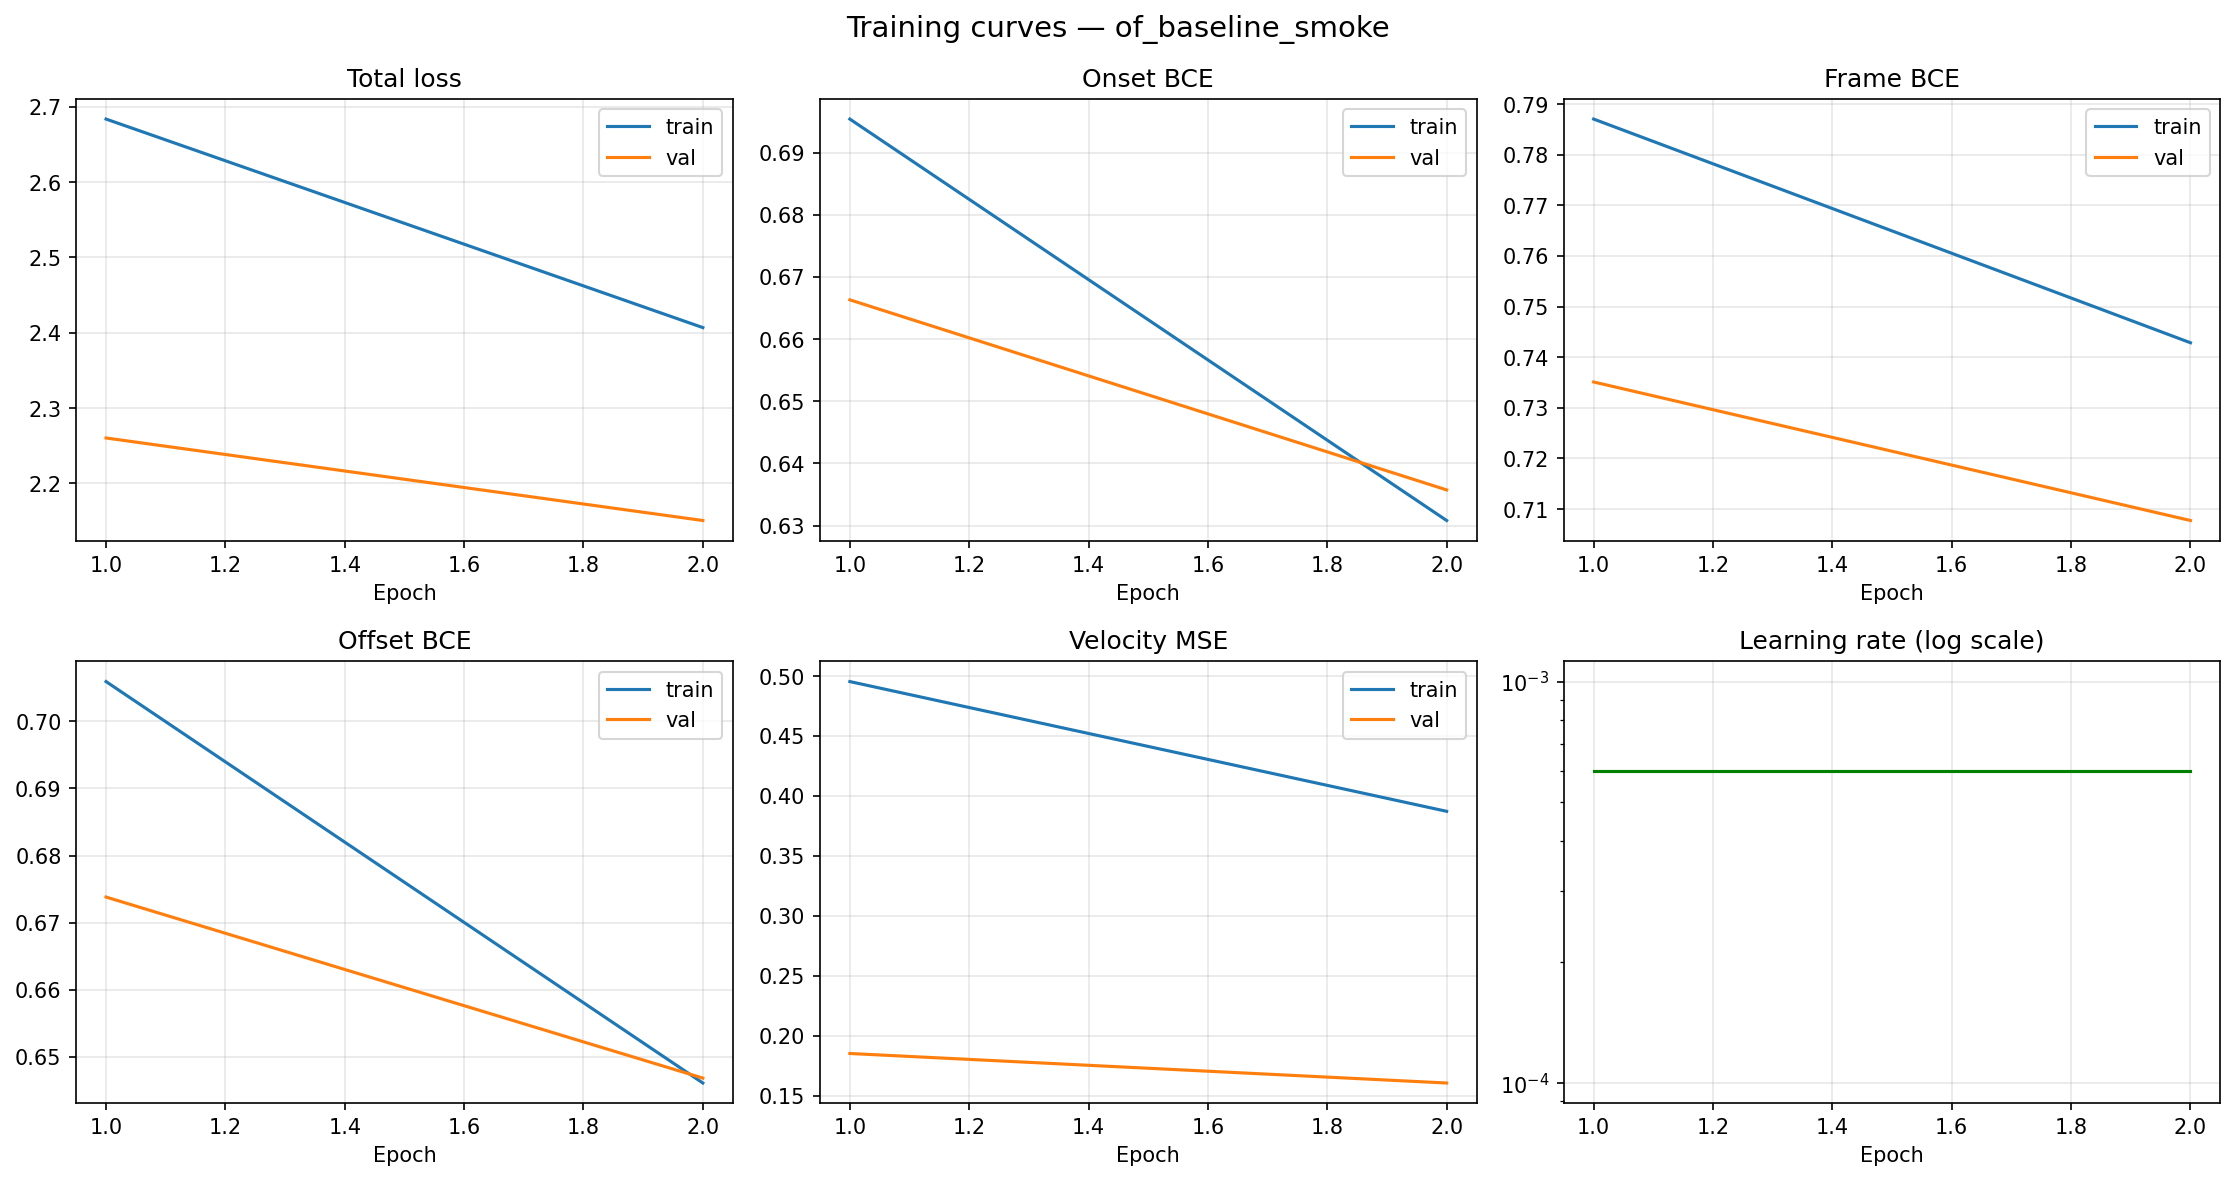

In [11]:
import matplotlib
matplotlib.use('Agg')   # headless
import matplotlib.pyplot as plt
import json

from evaluate.plots import plot_training_curves

metrics_path = run_dir.root / 'metrics.json'
save_path    = run_dir.plots / 'training_curves_final.png'

plot_training_curves(
    metrics_path = metrics_path,
    save_path    = save_path,
    title        = f"Training curves — {CONFIG['run_name']}",
)

# Also display in notebook
from IPython.display import Image
Image(str(save_path))

## Cell 7 — Evaluate on validation set

Runs the best checkpoint on the validation split and computes all AMT metrics.
Results saved to `runs/<run_name>/eval_validation/`.

In [13]:
from models.onsets_frames.evaluate import run_evaluation
import mir_eval

best_ckpt = str(run_dir.best_checkpoint_path())
print(f"Evaluating: {best_ckpt}")

val_summary = run_evaluation(
    checkpoint_path  = best_ckpt,
    maestro_root     = MAESTRO_ROOT,
    cache_dir        = CACHE_DIR,
    split            = 'validation',
    max_files        = CONFIG['max_files'],    # same subset for fair comparison
    save_midi        = True,
    save_plots       = True,
    model_complexity = CONFIG['model_complexity'],
)

print("\nValidation summary:")
for k in ['onset_f1', 'frame_f1', 'note_with_offset_f1', 'note_with_offset_vel_f1',
          'ea_offset_mae_ms', 'ea_chord_completeness']:
    print(f"  {k:35s}: {val_summary.get(k, 0):.4f}")

Evaluating: /content/drive/MyDrive/piano_amt/runs/of_baseline_smoke/checkpoints/best.pt
Device: cuda
Loaded checkpoint: /content/drive/MyDrive/piano_amt/runs/of_baseline_smoke/checkpoints/best.pt
  Trained for 2 epochs, val_loss=2.1509

Evaluating 5 files from 'validation' split...

  [1/5] MIDI-Unprocessed_17_R1_2006_01-06_ORIG_MID--AUDIO_17_R1_2006
      onset_f1=0.007  frame_f1=0.040  note+off_f1=0.004
  [2/5] MIDI-Unprocessed_07_R1_2009_04-05_ORIG_MID--AUDIO_07_R1_2009
      onset_f1=0.001  frame_f1=0.032  note+off_f1=0.000
  [3/5] MIDI-Unprocessed_02_R1_2009_03-06_ORIG_MID--AUDIO_02_R1_2009
      onset_f1=0.005  frame_f1=0.026  note+off_f1=0.004
  [4/5] MIDI-Unprocessed_11_R1_2009_06-09_ORIG_MID--AUDIO_11_R1_2009
      onset_f1=0.005  frame_f1=0.042  note+off_f1=0.001
  [5/5] ORIG-MIDI_01_7_6_13_Group__MID--AUDIO_03_R1_2013_wav--4
      onset_f1=0.014  frame_f1=0.050  note+off_f1=0.007

SUMMARY (validation, n=5)
  onset_f1                      : 0.0063
  frame_f1                  

## Cell 8 — Evaluate on test set

Only run this once per stage (after hyperparameters are finalised).
Results saved to `runs/<run_name>/eval_test/`.

In [14]:
test_summary = run_evaluation(
    checkpoint_path  = best_ckpt,
    maestro_root     = MAESTRO_ROOT,
    cache_dir        = CACHE_DIR,
    split            = 'test',
    max_files        = CONFIG['max_files'],
    save_midi        = True,
    save_plots       = True,
    model_complexity = CONFIG['model_complexity'],
)

print("\nTest summary:")
for k in ['onset_f1', 'frame_f1', 'note_with_offset_f1',
          'ea_offset_mae_ms', 'ea_chord_completeness']:
    print(f"  {k:35s}: {test_summary.get(k, 0):.4f}")

Device: cuda
Loaded checkpoint: /content/drive/MyDrive/piano_amt/runs/of_baseline_smoke/checkpoints/best.pt
  Trained for 2 epochs, val_loss=2.1509

Evaluating 5 files from 'test' split...

  [1/5] MIDI-Unprocessed_11_R1_2009_06-09_ORIG_MID--AUDIO_11_R1_2009
      onset_f1=0.005  frame_f1=0.044  note+off_f1=0.002
  [2/5] MIDI-Unprocessed_02_R1_2009_03-06_ORIG_MID--AUDIO_02_R1_2009
      onset_f1=0.002  frame_f1=0.041  note+off_f1=0.000
  [3/5] MIDI-Unprocessed_01_R1_2006_01-09_ORIG_MID--AUDIO_01_R1_2006
      onset_f1=0.005  frame_f1=0.053  note+off_f1=0.001
  [4/5] MIDI-Unprocessed_24_R1_2006_01-05_ORIG_MID--AUDIO_24_R1_2006
      onset_f1=0.007  frame_f1=0.047  note+off_f1=0.003
  [5/5] MIDI-Unprocessed_11_R1_2009_06-09_ORIG_MID--AUDIO_11_R1_2009
      onset_f1=0.004  frame_f1=0.043  note+off_f1=0.001

SUMMARY (test, n=5)
  onset_f1                      : 0.0046
  frame_f1                      : 0.0455
  note_with_offset_f1           : 0.0014
  note_with_offset_vel_f1       : 0.0006


## Cell 9 — Compare all runs

After training multiple stages / variants, use this cell to generate a
comparison table across all runs. Outputs CSV, LaTeX table, and bar chart.

In [15]:
from evaluate.compare import (
    compare_all_runs, print_comparison_table,
    save_comparison_csv, latex_table, plot_comparison_bar
)
import os

COMPARISON_DIR = f'{DRIVE_ROOT}/comparison'
os.makedirs(COMPARISON_DIR, exist_ok=True)

# Load all test results
rows = compare_all_runs(RUNS_DIR, split='test')

if rows:
    print_comparison_table(rows)

    save_comparison_csv(rows, f'{COMPARISON_DIR}/comparison_test.csv')

    print("\n--- LaTeX table ---")
    print(latex_table(rows))

    plot_comparison_bar(
        rows,
        save_path = f'{COMPARISON_DIR}/comparison_test.png',
        title     = 'Model comparison — test set'
    )

    from IPython.display import Image
    Image(f'{COMPARISON_DIR}/comparison_test.png')
else:
    print("No test results found yet. Run evaluation cells first.")


Run                 Onset F1    Frame F1    Note+Off F1   N+O+V F1    Frame Acc   Offset MAE(ms)    Chord Comp   N files 
-------------------------------------------------------------------------------------------------------------------------
of_baseline_smoke   0.0046      0.0455      0.0014        0.0006      0.0233      382.1791          0.0375       5       

CSV saved → /content/drive/MyDrive/piano_amt/comparison/comparison_test.csv

--- LaTeX table ---
\begin{table}[h]
\centering
\caption{AMT model comparison}
\label{tab:amt_comparison}
\begin{tabular}{lrrrrr}
\toprule
Run & Onset F1 & Frame F1 & Note+Offset F1 & N+O+V F1 & Offset MAE (ms) \\
\midrule
of\_baseline\_smoke & 0.0046 & 0.0455 & 0.0014 & 0.0006 & 382.1791 \\
\bottomrule
\end{tabular}
\end{table}
Comparison chart saved → /content/drive/MyDrive/piano_amt/comparison/comparison_test.png


## Cell 10 — Quick MIDI transcription demo

Load any audio file, run the best checkpoint, and save the decoded MIDI.
Useful for showing the system works end-to-end in your dissertation demo.

In [ ]:
import glob, torch
from src.audio import load_audio_as_log_mel
from src.dataloader import sliding_windows
from src.constants import FRAMES_PER_SECOND, N_KEYS, MAX_SEGMENT_FRAMES
from models.onsets_frames.model import OnsetsAndFrames
from models.onsets_frames.decode import rolls_to_midi_file

# ── Choose audio file ───────────────────────────────────────────────────────
# Use any .wav from MAESTRO or your own recording
test_wavs = glob.glob(f'{MAESTRO_ROOT}/**/*.wav', recursive=True)
AUDIO_PATH = test_wavs[0]   # first available file
OUT_MIDI   = f'/content/transcription_demo.mid'
print(f"Transcribing: {AUDIO_PATH}")

# ── Load model ──────────────────────────────────────────────────────────────
best_ckpt_path = str(run_dir.best_checkpoint_path())
model = OnsetsAndFrames(model_complexity=CONFIG['model_complexity'])
ckpt  = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(ckpt['model_state'])
model = model.to(device).eval()

# ── Compute mel ─────────────────────────────────────────────────────────────
log_mel = load_audio_as_log_mel(AUDIO_PATH, device=device)  # (229, T)
T_full  = log_mel.shape[1]
print(f"Audio length: {T_full / FRAMES_PER_SECOND:.1f} s  ({T_full} frames)")

# ── Sliding window inference ────────────────────────────────────────────────
pred_onset    = torch.zeros(T_full, N_KEYS)
pred_frame    = torch.zeros(T_full, N_KEYS)
pred_velocity = torch.zeros(T_full, N_KEYS)

windows = sliding_windows(log_mel, window_frames=MAX_SEGMENT_FRAMES)
with torch.no_grad():
    for win in windows:
        w_mel  = win['mel'].unsqueeze(0).to(device)    # (1,229,640)
        start  = win['start_frame']
        end    = min(start + MAX_SEGMENT_FRAMES, T_full)
        out    = model(w_mel)
        pred_onset[start:end]    = out['onset'][0, :end-start].cpu()
        pred_frame[start:end]    = out['frame'][0, :end-start].cpu()
        pred_velocity[start:end] = out['velocity'][0, :end-start].cpu()

print(f"Inference done. Decoding to MIDI...")

# ── Decode + save ───────────────────────────────────────────────────────────
rolls_to_midi_file(
    onset_roll    = pred_onset,
    frame_roll    = pred_frame,
    velocity_roll = pred_velocity,
    output_path   = OUT_MIDI,
    fps           = FRAMES_PER_SECOND,
)
print(f"MIDI saved to: {OUT_MIDI}")
print("Download it from the Colab file browser (left panel) or copy to Drive.")

Transcribing: /content/drive/MyDrive/piano_amt/maestro-v3.0.0/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.wav
Audio length: 194.6 s  (6081 frames)
Inference done. Decoding to MIDI...
MIDI saved → /content/transcription_demo.mid  (35619 notes)
MIDI saved to: /content/transcription_demo.mid
Download it from the Colab file browser (left panel) or copy to Drive.


---

## Scaling guide — what to change at each stage

```
Stage 0 — smoke (verify loop)
  max_files=5, model_complexity=16, epochs=2, batch_size=4
  Expected: training runs without error, val_loss finite

Stage 1 — tiny (model learns)
  max_files=30, model_complexity=16, epochs=5, batch_size=4
  Expected: val_loss decreases over epochs

Stage 2 — small (hyperparameter check)
  max_files=100, model_complexity=48, epochs=15, batch_size=8
  Expected: onset_f1 > 0.5 on validation

Stage 3 — medium (dissertation comparison)
  max_files=400, model_complexity=48, epochs=30, batch_size=8
  Expected: onset_f1 ≈ 0.8, frame_f1 ≈ 0.7  (comparable to paper)

Stage 4 — full (final results)
  max_files=None, model_complexity=48, epochs=30+, batch_size=8
  Expected: results matching Hawthorne 2018a / jongwook reported values
```
